In [277]:
import functions
import importlib
importlib.reload(functions)

from functions import *
import matplotlib.pyplot as plt


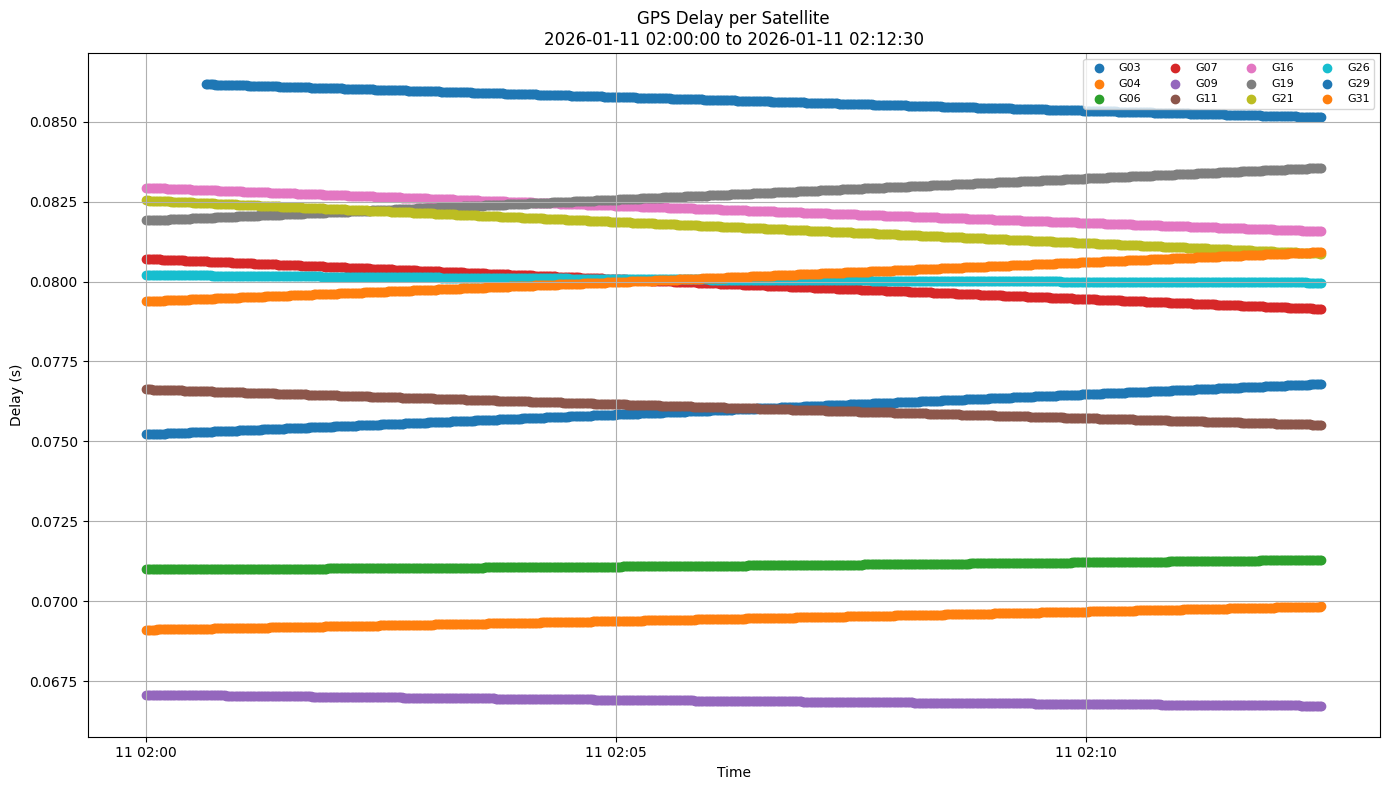

In [278]:
import pandas as pd
import matplotlib.pyplot as plt

C_MPS = 299_792_458.0

# load file
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# compute delay from pseudorange
df["delay_s"] = df["C1C_m"] / C_MPS

# satellites and time window
sv_order = [f"G{i:02d}" for i in range(1, 33)]
start_time = pd.Timestamp("2026-01-11 02:00:00")
end_time = start_time + pd.Timedelta(minutes=12.5)

# filter to requested window and satellites
window_df = df[
    (df["sv"].isin(sv_order)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df = window_df.sort_values(["sv", "time"])

# plot delay for each satellite
plt.figure(figsize=(14, 8))

for sv in sv_order:
    sat_df = window_df[window_df["sv"] == sv]
    if not sat_df.empty:
        plt.scatter(sat_df["time"], sat_df["delay_s"], label=sv)

plt.xlabel("Time")
plt.ylabel("Delay (s)")
plt.title(f"GPS Delay per Satellite\n{start_time} to {end_time}")
plt.legend(ncol=4, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [279]:
import pandas as pd
import numpy as np

C_MPS = 299_792_458.0

# load full extracted GPS observations
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# satellites and time window
sv_order = [ "G03", "G04", "G06","G07", "G09","G19","G21" , "G26", "G31"]
start_time = pd.Timestamp("2026-01-11 00:00:00")
end_time = start_time + pd.Timedelta(minutes=12.5)

# slice the window
window_df = df[
    (df["sv"].isin(sv_order)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df = window_df.sort_values(["time", "sv"]).reset_index(drop=True)
window_df["delay_s"] = window_df["C1C_m"] / C_MPS

print("rows:", len(window_df))
print("time min/max:", window_df["time"].min(), window_df["time"].max())
print("sats present:", window_df["sv"].unique())

# one dataframe per satellite BEFORE interpolation
sat_frames = {
    sv: grp.copy().reset_index(drop=True)
    for sv, grp in window_df.groupby("sv")
}

# print number of raw data points per satellite
print("\nraw data points per satellite:")
for sv in sv_order:
    n_points_before = len(sat_frames[sv]) if sv in sat_frames else 0
    print(f"{sv}: {n_points_before}")

# make sure all requested sats are present
for sv in sv_order:
    if sv not in sat_frames:
        print(f"Missing satellite: {sv}")

# build sat_data dict from raw observations
sat_data = {
    sv: {
        "time": sat_frames[sv]["time"].tolist(),
        "pseudorange_m": sat_frames[sv]["C1C_m"].tolist(),
        "delay_s": sat_frames[sv]["delay_s"].tolist(),
        "doppler_hz": sat_frames[sv]["D1C_hz"].tolist(),
    }
    for sv in sv_order
    if sv in sat_frames
}

# align into matrices with one common time index
pivot_pr = window_df.pivot(index="time", columns="sv", values="C1C_m").reindex(columns=sv_order)
pivot_delay = window_df.pivot(index="time", columns="sv", values="delay_s").reindex(columns=sv_order)
pivot_dopp = window_df.pivot(index="time", columns="sv", values="D1C_hz").reindex(columns=sv_order)

# count original non-missing data points before interpolation
print("\noriginal non-NaN points:")
print("pseudorange:", pivot_pr.notna().sum().sum())
print("delay:", pivot_delay.notna().sum().sum())
print("doppler:", pivot_dopp.notna().sum().sum())

# interpolate missing values inside the window
pivot_pr = pivot_pr.interpolate(limit_direction="both")
pivot_delay = pivot_delay.interpolate(limit_direction="both")
pivot_dopp = pivot_dopp.interpolate(limit_direction="both")

# arrays for simulator: shape = (n_sats, n_times)
pseudorange_list = pivot_pr.to_numpy(dtype=float).T
delay_list = pivot_delay.to_numpy(dtype=float).T
doppler_list = pivot_dopp.to_numpy(dtype=float).T
time_list = pivot_delay.index.to_numpy()

print("\ninterpolated array shapes:")
print("pseudorange_list shape:", pseudorange_list.shape)
print("delay_list shape:", delay_list.shape)
print("doppler_list shape:", doppler_list.shape)
print("time_list shape:", time_list.shape)

print("\ntotal matrix points after interpolation:")
print("pseudorange_list:", pseudorange_list.size)
print("delay_list:", delay_list.size)
print("doppler_list:", doppler_list.size)

# print RAW values before interpolation
print("\n===== RAW DATA PER SATELLITE (before interpolation) =====")
for sv in sv_order:
    if sv in sat_frames:
        raw_times = sat_frames[sv]["time"].to_numpy()
        raw_pr = sat_frames[sv]["C1C_m"].to_numpy()
        raw_delay = sat_frames[sv]["delay_s"].to_numpy()
        raw_dopp = sat_frames[sv]["D1C_hz"].to_numpy()
        n_points_before = len(raw_times)
    else:
        raw_times = np.array([])
        raw_pr = np.array([])
        raw_delay = np.array([])
        raw_dopp = np.array([])
        n_points_before = 0

    print(f"\n{sv}")
    print(" data points before interpolation:", n_points_before)
    print(" first raw times:", raw_times[:3])
    print(" first raw pseudoranges:", raw_pr[:3])
    print(" first raw delays:", raw_delay[:3])
    print(" first raw dopplers:", raw_dopp[:3])

# optional: print INTERPOLATED values separately
print("\n===== INTERPOLATED DATA PER SATELLITE =====")
for i, sv in enumerate(sv_order):
    print(f"\n{sv}")
    print(" first interpolated times:", time_list[:3])
    print(" first interpolated pseudoranges:", pseudorange_list[i, :3])
    print(" first interpolated delays:", delay_list[i, :3])
    print(" first interpolated dopplers:", doppler_list[i, :3])

rows: 4506
time min/max: 2026-01-11 00:00:00 2026-01-11 00:12:30
sats present: <StringArray>
['G03', 'G04', 'G06', 'G09', 'G19', 'G31']
Length: 6, dtype: str

raw data points per satellite:
G03: 751
G04: 751
G06: 751
G07: 0
G09: 751
G19: 751
G21: 0
G26: 0
G31: 751
Missing satellite: G07
Missing satellite: G21
Missing satellite: G26

original non-NaN points:
pseudorange: 4506
delay: 4506
doppler: 4506

interpolated array shapes:
pseudorange_list shape: (9, 751)
delay_list shape: (9, 751)
doppler_list shape: (9, 751)
time_list shape: (751,)

total matrix points after interpolation:
pseudorange_list: 6759
delay_list: 6759
doppler_list: 6759

===== RAW DATA PER SATELLITE (before interpolation) =====

G03
 data points before interpolation: 751
 first raw times: ['2026-01-11T00:00:00.000000' '2026-01-11T00:00:01.000000'
 '2026-01-11T00:00:02.000000']
 first raw pseudoranges: [19922865.917 19922922.998 19922980.16 ]
 first raw delays: [0.06645553 0.06645572 0.06645591]
 first raw dopplers: [-

In [280]:
print("NaNs after interpolation:")
print("pseudorange:", np.isnan(pseudorange_list).sum())
print("delay:", np.isnan(delay_list).sum())
print("doppler:", np.isnan(doppler_list).sum())

print("\nNaNs per sat in delay_list:")
for i, sv in enumerate(sv_order):
    print(sv, np.isnan(delay_list[i]).sum())

NaNs after interpolation:
pseudorange: 2253
delay: 2253
doppler: 2253

NaNs per sat in delay_list:
G03 0
G04 0
G06 0
G07 751
G09 0
G19 0
G21 751
G26 751
G31 0


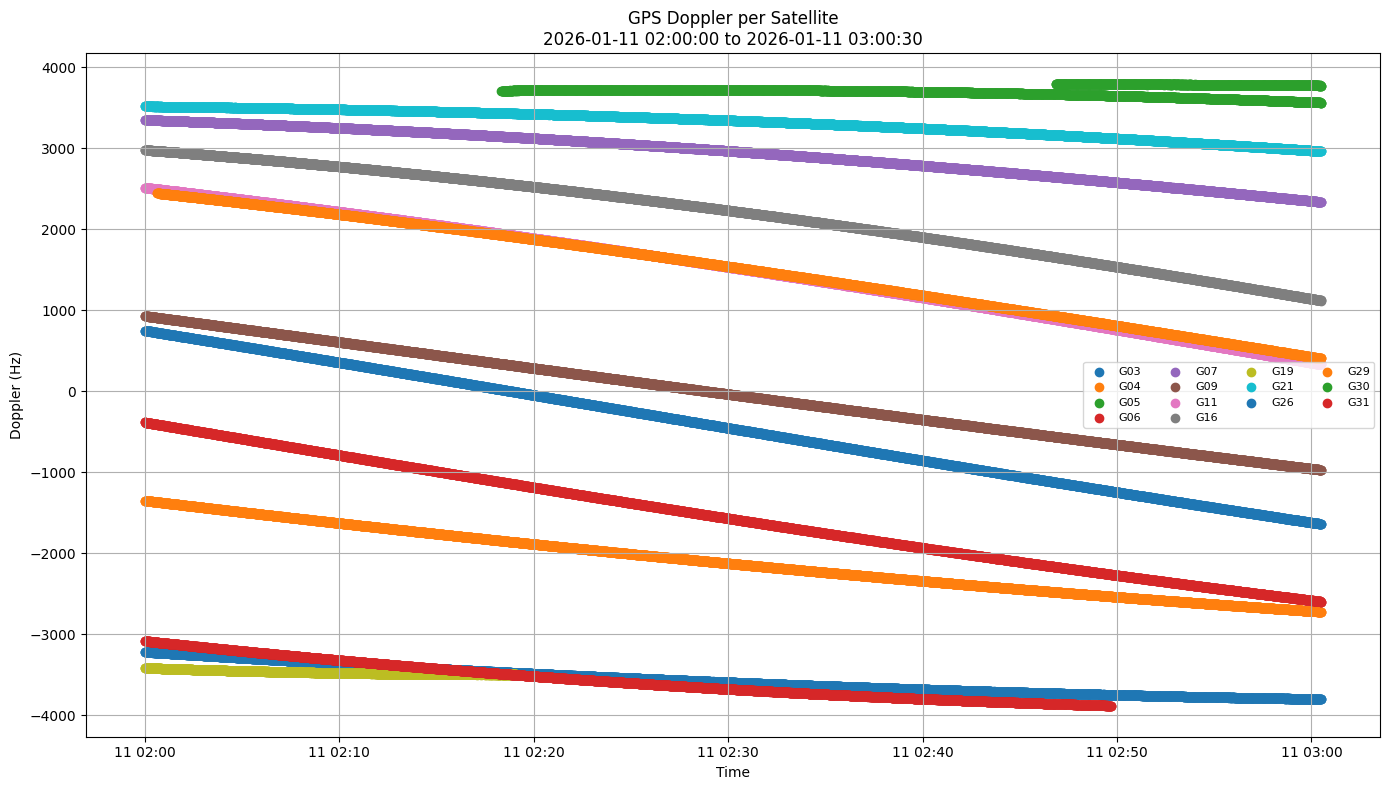

In [281]:
import pandas as pd
import matplotlib.pyplot as plt

# load file
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# satellites and time window
sv_order = [f"G{i:02d}" for i in range(1, 33)]
start_time = pd.Timestamp("2026-01-11 02:00:00")
end_time = start_time + pd.Timedelta(minutes=60.5)

# filter to requested window and satellites
window_df = df[
    (df["sv"].isin(sv_order)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df = window_df.sort_values(["sv", "time"])

# plot doppler for each satellite
plt.figure(figsize=(14, 8))

for sv in sv_order:
    sat_df = window_df[window_df["sv"] == sv]
    if not sat_df.empty:
        plt.scatter(sat_df["time"], sat_df["D1C_hz"], label=sv)

plt.xlabel("Time")
plt.ylabel("Doppler (Hz)")
plt.title(f"GPS Doppler per Satellite\n{start_time} to {end_time}")
plt.legend(ncol=4, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [282]:
sv_nums = [3, 4, 6, 9, 31]
#sv_order = [ "G03", "G04", "G06","G07", "G09","G19","G21" , "G26","G29", "G31"]

sv_labels = [f"G{i:02d}" for i in sv_nums]

receiver_ecef = ECEF(buddinge[0], buddinge[1], buddinge[2])

res = {sv: modulo2_frames_runs(sv, Z_count_start, sv) for sv in sv_nums}
rho = {
    sv: np.sqrt(sum((ehpm_to_ECEFlocation(sv) - receiver_ecef) ** 2))
    for sv in sv_nums
}
chips = {
    sv: np.frombuffer(res[sv].unpack(), dtype=np.uint8)
    for sv in sv_nums
}

chip_streams_01 = [chips[sv] for sv in sv_nums]
distances_m = np.array([rho[sv] for sv in sv_nums], dtype=float)
phase0 = np.array([2 * np.pi / (i + 1) for i in range(len(sv_nums))], dtype=float)

doppler_list = np.array(
    [sat_frames[f"G{sv:02d}"]["D1C_hz"].tolist() for sv in sv_nums],
    dtype=float
)

delay_list = np.array(
    [sat_frames[f"G{sv:02d}"]["delay_s"].tolist() for sv in sv_nums],
    dtype=float
)

amplitudes = np.full(len(sv_nums), 0.1, dtype=float)

print(len(delay_list))

5


In [283]:
C = 299792458.0
GPS_UTC_LEAP_SECONDS = 18  # valid for 2026 file

def check_gps_week_crossing(t_k): # GPS week rollover check
    if t_k > 302400:
        t_k -= 604800
    elif t_k < -302400:
        t_k += 604800
    return t_k


def datetime_to_gpsweek_and_sow(dt, leap_seconds=GPS_UTC_LEAP_SECONDS):
    gps0 = pd.Timestamp("1980-01-06T00:00:00Z")     #start of GPS time, has rolled over a few times since then

    dt = pd.Timestamp(dt)
    if dt.tzinfo is None:
        dt = dt.tz_localize("UTC")
    else:
        dt = dt.tz_convert("UTC")

    # OBS RINEX time is treated as UTC-like here.
    # Convert UTC -> GPS time.
    dt_gps = dt + pd.Timedelta(seconds=leap_seconds)

    sec = (dt_gps - gps0).total_seconds()
    week = int(sec // 604800)
    sow = float(sec - week * 604800)

    return week, sow    #week number and sec of week

def select_eph_idx(SV: int, t_gps_sow: float): #takes SV and gps sec of week (ie plus the 18 sec)
    sv_key = SV_input_dict[SV]                  # converts SV to "Gxy" format
    eph = tables[sv_key]                        # pulls empheris data

    toes = eph["Toe"].to_numpy(dtype=float)     # time of ephemeris pulled

    dts = np.array([
        check_gps_week_crossing(t_gps_sow - toe)    # finds all the toes in the emphemeris data
        for toe in toes
    ])

    return int(np.argmin(np.abs(dts)))          # chooses the closest one

def ehpm_to_ECEFlocation_at_time(SV: int, t_gps_sow: float, eph_idx=None):  # finds the location in ECEF at a given time
    mu = 3.986005e14                            # grav const
    omegaDot_e = 7.2921151467e-5                # earth rotation rate

    sv_key = SV_input_dict[SV]
    eph = tables[sv_key]

    if eph_idx is None:                         
        eph_idx = select_eph_idx(SV, t_gps_sow) # redundancy
                                                # defining of all needed emphemris data from rinex table
    M_o = eph["M0"].iloc[eph_idx]               # Mean anomally at reffrence time(toe), where is it in the orbit 
    Deltan = eph["DeltaN"].iloc[eph_idx]        # correction to mean motion time
    a = eph["sqrtA"].iloc[eph_idx] ** 2         # semi major axis
    e = eph["e"].iloc[eph_idx]                  # eccentricity
    w = eph["omega"].iloc[eph_idx]              # orientation of the orbital plane, angle from assending node to perigee

    C_uc = eph["Cuc"].iloc[eph_idx]             # corrects the argument of latitude as the cosine part
    C_us = eph["Cus"].iloc[eph_idx]             # corrects the argument of latitude as the sine part
    C_rs = eph["Crs"].iloc[eph_idx]             # corrects the orbital radius as the sine part
    C_rc = eph["Crc"].iloc[eph_idx]             # corrects the orbital radius as the cosine part

    i_0 = eph["i0"].iloc[eph_idx]               # inclination at reffrence time(toe)
    i_dot = eph["IDOT"].iloc[eph_idx]           # change of inclination over time
    C_ic = eph["Cic"].iloc[eph_idx]             # cosine correction to inclination
    C_is = eph["Cis"].iloc[eph_idx]             # sine correction to inclination

    Omega0 = eph["Omega0"].iloc[eph_idx]        # longitude of ascending node at reffrence time, 
                                                # so where the SV crosses the equatorial plane going north
    OmegaDot = eph["OmegaDot"].iloc[eph_idx]    # rate of right ascention, how fast is omega0 changing, acounts for earth rotation

    t_oe = eph["Toe"].iloc[eph_idx]             # time of emphemeris reffrence time for when the orbital parameters where correct

    t_k = check_gps_week_crossing(t_gps_sow - t_oe) # time since reffrence(toe)

    M_k = M_o + ((np.sqrt(mu) / np.sqrt(a**3)) + Deltan) * t_k  # compute mean anomaly

    E_k = solve_kepler_E(M_k, e)                # solve the kepler equations iteratively

    v_k = np.arctan2(                           # eccentric anomally to true anomally
        np.sqrt(1 - e**2) * np.sin(E_k),
        np.cos(E_k) - e
    )

    phi_k = w + v_k                             

    u_k = phi_k + C_uc * np.cos(2 * phi_k) + C_us * np.sin(2 * phi_k)   # correction to latitiude

    r_k = (                                     # corrected orbital radius
        a * (1 - e * np.cos(E_k))
        + C_rc * np.cos(2 * phi_k)
        + C_rs * np.sin(2 * phi_k)
    )

    i_k = (                                     # correced inclination
        i_0
        + i_dot * t_k
        + C_ic * np.cos(2 * phi_k)
        + C_is * np.sin(2 * phi_k)
    )

    lambda_k = Omega0 + (OmegaDot - omegaDot_e) * t_k - omegaDot_e * t_oe   # corrected longtitude of ascending node

    rk_vec = np.array([r_k, 0, 0], dtype=float) # rotate into ECEF

    XYZ = R3(-lambda_k) @ R1(-i_k) @ R3(-u_k) @ rk_vec  # apply rotaions and such that it becomes ECEF

    return np.asarray(XYZ, dtype=float).reshape(3)      # xyz output in meters


def satellite_clock_correction(SV: int, t_gps_sow: float, eph_idx=None):
    """
    Satellite clock correction in seconds.
    """
    F = -4.442807633e-10                                # relativistic correction constant

    sv_key = SV_input_dict[SV]
    eph = tables[sv_key]

    if eph_idx is None:
        eph_idx = select_eph_idx(SV, t_gps_sow)

    af0 = eph["af0"].iloc[eph_idx]                      # satelite clock correction
    af1 = eph["af1"].iloc[eph_idx]                      # satalite clock drift
    af2 = eph["af2"].iloc[eph_idx]                      # satelite clock drift rate
    TGD = eph["TGD"].iloc[eph_idx]                      # satelite hardware timing bias between clock ref and tx

    sqrtA = eph["sqrtA"].iloc[eph_idx]                  # square  root of the semi major axis
    e = eph["e"].iloc[eph_idx]                          
    M0 = eph["M0"].iloc[eph_idx]                        
    DeltaN = eph["DeltaN"].iloc[eph_idx]                
    toe = eph["Toe"].iloc[eph_idx]

    toc_time = eph["time"].iloc[eph_idx]                # compute sec of week(SOW)
    _, toc_sow = datetime_to_gpsweek_and_sow(toc_time)

    dt_clock = check_gps_week_crossing(t_gps_sow - toc_sow) #time since clock ref

    mu = 3.986005e14
    A = sqrtA ** 2
    tk = check_gps_week_crossing(t_gps_sow - toe)

    n0 = np.sqrt(mu / A**3)
    n = n0 + DeltaN
    Mk = M0 + n * tk
    Ek = solve_kepler_E(Mk, e)

    dtr = F * e * sqrtA * np.sin(Ek)                    # computes for reletavistic correction

    # L1 C/A convention
    dtsv = af0 + af1 * dt_clock + af2 * dt_clock**2 + dtr - TGD # full clock correction

    return float(dtsv)


def get_obs_code_type(obs):
    preferred = ["C1C", "C1", "C1W", "C1P"]

    for key in preferred:
        if key in obs.data_vars:
            return key

    raise ValueError(f"No L1 pseudorange observable found. Available: {list(obs.data_vars)}")


def sv_string_to_int(sv):                               # its in the name
    sv = str(sv)
    if not sv.startswith("G"):
        raise ValueError(f"Not GPS: {sv}")
    return int(sv[1:])

def clean_delay_from_obs_epoch(
    SV: int,                                    
    t_rx_sow: float,
    rx_ecef,
    P_obs=None,
    include_sat_clock=True,
    iterations=6,
):                                                      
    rx_ecef = np.asarray(rx_ecef, dtype=float).reshape(3)   # normalize receiver pos

    eph_idx = select_eph_idx(SV, t_rx_sow)                  

    # Use OBS pseudorange only as initial transmit-time guess.
    if P_obs is not None and np.isfinite(P_obs):
        t_tx_sow = t_rx_sow - float(P_obs) / C
    else:
        t_tx_sow = t_rx_sow - 0.075

    for _ in range(iterations):                             # runs for a number of times getting the best posible result    
        sat_ecef = ehpm_to_ECEFlocation_at_time(SV, t_tx_sow, eph_idx)  
        rho = np.linalg.norm(sat_ecef - rx_ecef)

        if include_sat_clock:
            dtsv = satellite_clock_correction(SV, t_tx_sow, eph_idx)
        else:
            dtsv = 0.0

        pseudorange = rho - C * dtsv
        t_tx_sow = t_rx_sow - pseudorange / C

    sat_ecef = ehpm_to_ECEFlocation_at_time(SV, t_tx_sow, eph_idx)
    rho = np.linalg.norm(sat_ecef - rx_ecef)

    if include_sat_clock:
        dtsv = satellite_clock_correction(SV, t_tx_sow, eph_idx)
    else:
        dtsv = 0.0

    pseudorange = rho - C * dtsv                            # uses corrections on range
    delay_seconds = pseudorange / C                         # calc delay

    return {
        "SV": SV,
        "t_rx_sow": float(t_rx_sow),
        "t_tx_sow": float(t_tx_sow),
        "delay_seconds": float(delay_seconds),
        "pseudorange_m": float(pseudorange),
        "rho_m": float(rho),
        "sat_clock_s": float(dtsv),
        "sat_clock_m": float(C * dtsv),
        "eph_idx": int(eph_idx),
        "sat_x": float(sat_ecef[0]),
        "sat_y": float(sat_ecef[1]),
        "sat_z": float(sat_ecef[2]),
        "P_obs": None if P_obs is None else float(P_obs),
    }

def build_delay_list_from_obs_df_simple(
    df,
    rx_ecef,
    max_epochs=None,
    include_sat_clock=True,
):
    """
    Build clean simulator delay list from your OBS DataFrame format:

        time | sv | C1C_m | D1C_hz

    Uses:
      time  -> receiver epoch t_rx
      sv    -> visible GPS satellite
      C1C_m -> initial t_tx guess only

    Final delay is calculated from NAV ephemeris + receiver ECEF,
    not from raw C1C_m.
    """

    required = {"time", "sv", "C1C_m"}                      # ensures the right data is there
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    rows = []

    work = df.copy()
    work["time"] = pd.to_datetime(work["time"])

    obs_times = work["time"].dropna().drop_duplicates().sort_values().to_numpy()    # one timestamp per receiver epoch

    if max_epochs is not None:                              # changing amount of epochs
        obs_times = obs_times[:max_epochs]

    for epoch_idx, obs_time in enumerate(obs_times):        # convert to GPS week and SOW for each epoch
        gps_week, t_rx_sow = datetime_to_gpsweek_and_sow(obs_time)  

        epoch_rows = work[work["time"] == obs_time]         # select all rows for chosen epoch

        for _, row in epoch_rows.iterrows():                # 
            sv_str = str(row["sv"])

            if not sv_str.startswith("G"):                  # make sure we have the right column
                continue

            SV = int(sv_str[1:])                            # conv to int

            if SV not in SV_input_dict:                     # redundancy
                continue

            sv_key = SV_input_dict[SV]

            if sv_key not in tables:                        # redundancy
                continue

            P_obs = float(row["C1C_m"])                     # pull observed pseudo (from buddinge)

            if not np.isfinite(P_obs):                      # redundancy
                continue

            try:
                out = clean_delay_from_obs_epoch(
                    SV=SV,
                    t_rx_sow=t_rx_sow,
                    rx_ecef=rx_ecef,
                    P_obs=P_obs,
                    include_sat_clock=include_sat_clock,
                )

                out["epoch_idx"] = epoch_idx
                out["obs_time"] = pd.Timestamp(obs_time)
                out["gps_week"] = gps_week
                out["sv_str"] = sv_str
                out["C1C_m"] = P_obs

                if "D1C_hz" in row:
                    out["D1C_hz"] = row["D1C_hz"]

                rows.append(out)

            except Exception as err:
                print(f"Failed {sv_str} at {pd.Timestamp(obs_time)}: {err}")

    return pd.DataFrame(rows)


In [284]:
rx_ecef = ECEF(55.738957, 12.500242, 20)

In [285]:
delay_df = build_delay_list_from_obs_df_simple(
    df=df,
    rx_ecef=rx_ecef,
    max_epochs=751,
    include_sat_clock=True,
)

In [286]:
delay_df["rinex_minus_clean_m"] = delay_df["C1C_m"] - delay_df["pseudorange_m"]
wanted_sats = ["G03", "G04", "G06", "G09", "G31"]

delay_5sat = delay_df[delay_df["sv_str"].isin(wanted_sats)].copy()

print(delay_5sat[[
    #"obs_time",
    "sv_str",
    #"t_rx_sow",
    #"t_tx_sow",
    #"C1C_m",
    #"pseudorange_m",
    "rinex_minus_clean_m",
    #"delay_seconds",
    #"rho_m",
    #"sat_clock_m",
]].head(30))



   sv_str  rinex_minus_clean_m
2     G03         48776.689418
3     G04         58486.453308
4     G06         61058.949690
5     G09         62557.365521
11    G31         55427.734448
14    G03         48775.025234
15    G04         58484.884328
16    G06         61058.276896
17    G09         62556.886945
23    G31         55425.578422
26    G03         48773.344635
27    G04         58483.230771
28    G06         61057.496148
29    G09         62556.218470
35    G31         55423.404079
38    G03         48771.540622
39    G04         58481.626622
40    G06         61056.604430
41    G09         62555.615083
47    G31         55421.039402
50    G03         48769.856198
51    G04         58480.220872
52    G06         61055.916727
53    G09         62555.076770
59    G31         55418.999377
62    G03         48768.213365
63    G04         58478.774506
64    G06         61055.240024
65    G09         62554.559518
71    G31         55416.923988


In [287]:

delay_arrays = [
    delay_df[delay_df["sv_str"] == sat]
        .sort_values("obs_time")["delay_seconds"]
        .to_numpy()
    for sat in wanted_sats
]

In [288]:
#KEEEEEP
import numpy as np

C_MPS = 299_792_458.0

def sample_chip_sequences_to_iq_file_variable_delay_doppler(
    chip_streams_01,
    delay_list,
    out_file="gps_signal_iq_fc32.dat",
    chip_rate=1.023e6,
    fs=4.0e6,
    doppler_hz_chunks=None,
    phase0=None,
    amplitudes=None,
    use_relative_delays=False,
    common_delay_s=0.0,
    noise_std=0.02,
    rng=None,
    epoch_times_s=None,
    max_chunks=None,
    verbose=True,
):
    """
    Generate complex baseband IQ from chip streams with time-varying code delay
    and time-varying carrier Doppler.

    Important:
    - delay_list[s, k] is the total propagation/code delay for satellite s at epoch k.
    - doppler_hz_chunks[s, k] is the carrier Doppler for satellite s at epoch k.
    - epoch_times_s defines the time axis of those values.
    - Code timing is driven by t - delay(t), so satellites can catch up / drift apart.
    """

    if len(chip_streams_01) == 0:
        raise ValueError("Need at least one chip stream")

    if rng is None:
        rng = np.random.default_rng()

    n_sats = len(chip_streams_01)

    chips = []
    for k, chips_01 in enumerate(chip_streams_01):
        arr = np.asarray(chips_01, dtype=np.uint8)
        if not np.all((arr == 0) | (arr == 1)):
            raise ValueError(f"Chip stream {k} contains values other than 0/1")
        chips.append(arr)
    lengths = [len(c) for c in chips]
    if len(set(lengths)) != 1:
        raise ValueError(f"All chip streams must have same length, got {lengths}")

    n_chips = lengths[0]
    signal_duration_s = n_chips / chip_rate
    n_signal_samples = int(np.ceil(signal_duration_s * fs))

    delay_list = np.asarray(delay_list, dtype=np.float64)
    if delay_list.ndim != 2:
        raise ValueError("delay_list must be 2D")
    if delay_list.shape[0] != n_sats:
        raise ValueError("delay_list first dimension must equal number of satellites")

    n_epochs = delay_list.shape[1]
    if n_epochs < 1:
        raise ValueError("delay_list must contain at least one epoch")

    if epoch_times_s is None:
        epoch_times_s = np.arange(n_epochs, dtype=np.float64)
    else:
        epoch_times_s = np.asarray(epoch_times_s, dtype=np.float64)
        if epoch_times_s.ndim != 1 or len(epoch_times_s) != n_epochs:
            raise ValueError("epoch_times_s must have shape (n_epochs,)")
        if np.any(np.diff(epoch_times_s) <= 0):
            raise ValueError("epoch_times_s must be strictly increasing")
        if epoch_times_s[0] < 0.0:
            raise ValueError("epoch_times_s must start at or after 0")

    # Shift epoch_times so signal starts at t=0
    epoch_times_s = epoch_times_s - epoch_times_s[0]

    if use_relative_delays:
        delay_list = delay_list - np.min(delay_list, axis=0, keepdims=True)

    delay_list = delay_list + float(common_delay_s)

    if phase0 is None:
        phase0 = np.zeros(n_sats, dtype=np.float64)
    else:
        phase0 = np.asarray(phase0, dtype=np.float64)
        if len(phase0) != n_sats:
            raise ValueError("phase0 must have same length as chip_streams_01")

    if amplitudes is None:
        amplitudes = np.ones(n_sats, dtype=np.float32)
    else:
        amplitudes = np.asarray(amplitudes, dtype=np.float32)
        if len(amplitudes) != n_sats:
            raise ValueError("amplitudes must have same length as chip_streams_01")

    if doppler_hz_chunks is None:
        doppler_hz_chunks = np.zeros((n_sats, n_epochs), dtype=np.float64)
    else:
        doppler_hz_chunks = np.asarray(doppler_hz_chunks, dtype=np.float64)
        if doppler_hz_chunks.ndim != 2:
            raise ValueError("doppler_hz_chunks must be 2D")
        if doppler_hz_chunks.shape == (n_sats, n_epochs):
            pass
        elif doppler_hz_chunks.shape == (n_epochs, n_sats):
            doppler_hz_chunks = doppler_hz_chunks.T
        else:
            raise ValueError(
                f"doppler_hz_chunks must have shape ({n_sats}, {n_epochs}) "
                f"or ({n_epochs}, {n_sats}), got {doppler_hz_chunks.shape}"
            )

    # Build segments from epoch grid
    if n_epochs == 1:
        seg_start_times = np.array([0.0], dtype=np.float64)
        seg_end_times = np.array([signal_duration_s], dtype=np.float64)
    else:
        seg_start_times = epoch_times_s.copy()
        seg_end_times = np.empty_like(seg_start_times)
        seg_end_times[:-1] = epoch_times_s[1:]
        seg_end_times[-1] = signal_duration_s

    # Clip to signal duration
    valid_seg = seg_start_times < signal_duration_s
    seg_start_times = seg_start_times[valid_seg]
    seg_end_times = np.minimum(seg_end_times[valid_seg], signal_duration_s)

    if max_chunks is not None:
        n_segments = min(len(seg_start_times), int(max_chunks))
        seg_start_times = seg_start_times[:n_segments]
        seg_end_times = seg_end_times[:n_segments]
    else:
        n_segments = len(seg_start_times)

    phase_acc = phase0.astype(np.float64).copy()
    chip_rate_over_fs = chip_rate / fs
    two_pi = 2.0 * np.pi

    if verbose:
        print("delay_list shape:", delay_list.shape)
        print("doppler_hz_chunks shape:", doppler_hz_chunks.shape)
        print("epoch_times_s[0:5]:", epoch_times_s[:5])
        print("signal duration (s):", signal_duration_s)
        print("signal samples:", n_signal_samples)
        print("segments:", n_segments)

    total_written = 0

    with open(out_file, "wb") as f:
        for seg_idx in range(n_segments):
            t0 = seg_start_times[seg_idx]
            t1 = seg_end_times[seg_idx]

            if t1 <= t0:
                continue

            start = int(np.round(t0 * fs))
            stop = int(np.round(t1 * fs))
            start = max(start, 0)
            stop = min(stop, n_signal_samples)

            n_chunk_samples = stop - start
            if n_chunk_samples <= 0:
                continue

            sample_idx = np.arange(start, stop, dtype=np.float64)
            t_abs = sample_idx / fs
            dt = t_abs - t0

            i_sum = np.zeros(n_chunk_samples, dtype=np.float32)
            q_sum = np.zeros(n_chunk_samples, dtype=np.float32)

            seg_duration = t1 - t0
            if seg_duration > 0:
                alpha = (t_abs - t0) / seg_duration
            else:
                alpha = np.zeros_like(t_abs)

            for s in range(n_sats):
                d0 = delay_list[s, seg_idx]
                d1 = delay_list[s, seg_idx + 1] if seg_idx < n_epochs - 1 else d0

                f0 = doppler_hz_chunks[s, seg_idx]
                f1 = doppler_hz_chunks[s, seg_idx + 1] if seg_idx < n_epochs - 1 else f0

                # code timing uses time-varying delay, not frozen initial delay
                delay_t = d0 + (d1 - d0) * alpha
                src_sample_idx = sample_idx - delay_t * fs

                valid = (src_sample_idx >= 0.0) & (src_sample_idx < n_signal_samples - 1)
                if not np.any(valid):
                    if seg_duration > 0:
                        fdot = (f1 - f0) / seg_duration
                        phase_end = phase_acc[s] + two_pi * (
                            f0 * seg_duration + 0.5 * fdot * seg_duration * seg_duration
                        )
                        phase_acc[s] = phase_end % two_pi
                    continue

                # Carrier phase continuous with linearly varying Doppler
                if seg_duration > 0:
                    fdot = (f1 - f0) / seg_duration
                    phase_chunk = phase_acc[s] + two_pi * (
                        f0 * dt + 0.5 * fdot * dt * dt
                    )
                    phase_end = phase_acc[s] + two_pi * (
                        f0 * seg_duration + 0.5 * fdot * seg_duration * seg_duration
                    )
                else:
                    phase_chunk = np.full_like(dt, phase_acc[s])
                    phase_end = phase_acc[s]

                cos_chunk = np.cos(phase_chunk).astype(np.float32)
                sin_chunk = np.sin(phase_chunk).astype(np.float32)
                phase_acc[s] = phase_end % two_pi

                chip_pos = src_sample_idx[valid] * chip_rate_over_fs

                chip_i0 = np.floor(chip_pos).astype(np.int64)
                frac_chip = (chip_pos - chip_i0).astype(np.float32)

                chip_i0 = np.clip(chip_i0, 0, n_chips - 1)
                chip_i1 = np.clip(chip_i0 + 1, 0, n_chips - 1)

                c0 = (2.0 * chips[s][chip_i0].astype(np.float32)) - 1.0
                c1 = (2.0 * chips[s][chip_i1].astype(np.float32)) - 1.0

                baseband = (1.0 - frac_chip) * c0 + frac_chip * c1

                i_sum[valid] += amplitudes[s] * baseband * cos_chunk[valid]
                q_sum[valid] += amplitudes[s] * baseband * sin_chunk[valid]

            if noise_std > 0:
                i_sum += rng.normal(0.0, noise_std, n_chunk_samples).astype(np.float32)
                q_sum += rng.normal(0.0, noise_std, n_chunk_samples).astype(np.float32)

            iq = np.empty(2 * n_chunk_samples, dtype=np.float32)
            iq[0::2] = i_sum
            iq[1::2] = q_sum
            iq.tofile(f)

            total_written += n_chunk_samples

            if verbose:
                print(
                    f"segment {seg_idx + 1}/{n_segments}: "
                    f"t=[{t0:.6f}, {t1:.6f}) s, samples={n_chunk_samples}"
                )

    return total_written

#code delay tilføjet giver en Chi square test som forbliver omkring 112600 ish aka der er markant mindre drift!!

In [289]:
delay_matrix = np.vstack(delay_arrays)

In [290]:
#KEEEEEEP

epoch_times_s = np.arange(delay_matrix.shape[1], dtype=np.float64)
n_written = sample_chip_sequences_to_iq_file_variable_delay_doppler(
    chip_streams_01=chip_streams_01,
    delay_list=delay_matrix,
    doppler_hz_chunks=doppler_list,
    epoch_times_s=epoch_times_s,
    out_file="gps_signal2_iq_fc32.dat",
    fs=4.0e6,
    chip_rate=1.023e6,
    noise_std=0.00,
    max_chunks=50,   # only first 50 segments
    verbose=True,
)

delay_list shape: (5, 751)
doppler_hz_chunks shape: (5, 751)
epoch_times_s[0:5]: [0. 1. 2. 3. 4.]
signal duration (s): 750.0
signal samples: 3000000000
segments: 50
segment 1/50: t=[0.000000, 1.000000) s, samples=4000000
segment 2/50: t=[1.000000, 2.000000) s, samples=4000000
segment 3/50: t=[2.000000, 3.000000) s, samples=4000000
segment 4/50: t=[3.000000, 4.000000) s, samples=4000000
segment 5/50: t=[4.000000, 5.000000) s, samples=4000000
segment 6/50: t=[5.000000, 6.000000) s, samples=4000000
segment 7/50: t=[6.000000, 7.000000) s, samples=4000000
segment 8/50: t=[7.000000, 8.000000) s, samples=4000000
segment 9/50: t=[8.000000, 9.000000) s, samples=4000000
segment 10/50: t=[9.000000, 10.000000) s, samples=4000000
segment 11/50: t=[10.000000, 11.000000) s, samples=4000000
segment 12/50: t=[11.000000, 12.000000) s, samples=4000000
segment 13/50: t=[12.000000, 13.000000) s, samples=4000000
segment 14/50: t=[13.000000, 14.000000) s, samples=4000000
segment 15/50: t=[14.000000, 15.00000

In [291]:
s = 0
n_epochs = delay_list.shape[1]
epoch_times_s = np.arange(n_epochs, dtype=np.float64)

d = np.asarray(delay_list[s], dtype=float)
t = np.asarray(epoch_times_s, dtype=float)

print("n epochs:", len(t))
print("t[0:5] =", t[:5])
print("dt unique-ish:", np.unique(np.round(np.diff(t), 9))[:10])
print("delay[0:5] =", d[:5])
print("delay min/max [s]:", d.min(), d.max())
print("delay span [m]:", (d.max() - d.min()) * C_MPS)

n epochs: 751
t[0:5] = [0. 1. 2. 3. 4.]
dt unique-ish: [1.]
delay[0:5] = [0.06645553 0.06645572 0.06645591 0.0664561  0.06645629]
delay min/max [s]: 0.06645552743358206 0.06668881155442542
delay span [m]: 69936.82000000094


In [292]:
L1_HZ = 1575.42e6
C_MPS = 299_792_458.0

s = 0
d = delay_list[s]
t = np.arange(len(d), dtype=float)

range_m = d * C_MPS
range_rate = np.gradient(range_m, t)   # m/s

fd_from_delay = -(range_rate / C_MPS) * L1_HZ

print("range-rate min/max [m/s]:", range_rate.min(), range_rate.max())
print("doppler-from-delay min/max [Hz]:", fd_from_delay.min(), fd_from_delay.max())

if doppler_list is not None:
    f = np.asarray(doppler_list[s], dtype=float)
    print("input doppler min/max [Hz]:", f.min(), f.max())
    print("difference min/max [Hz]:", (f - fd_from_delay).min(), (f - fd_from_delay).max())

range-rate min/max [m/s]: 57.08100000023842 129.15100000053644
doppler-from-delay min/max [Hz]: -678.6930858041969 -299.9626795827386
input doppler min/max [Hz]: -679.526 -299.556
difference min/max [Hz]: -1.5528566480801373 1.7260237288059557


In [293]:
import numpy as np

print("delay_list shape:", delay_list.shape)
print("total NaNs:", np.isnan(delay_list).sum())

nan_per_sat = np.isnan(delay_list).sum(axis=1)
nan_per_epoch = np.isnan(delay_list).sum(axis=0)

print("NaNs per sat:", nan_per_sat)
print("sats with NaNs:", np.where(nan_per_sat > 0)[0])
print("max NaNs in one epoch:", nan_per_epoch.max())
print("epochs with any NaNs:", np.where(nan_per_epoch > 0)[0][:20])

delay_list shape: (5, 751)
total NaNs: 0
NaNs per sat: [0 0 0 0 0]
sats with NaNs: []
max NaNs in one epoch: 0
epochs with any NaNs: []


In [294]:
delay_list[8][318]

IndexError: index 8 is out of bounds for axis 0 with size 5

In [ ]:
import numpy as np

C_MPS = 299_792_458.0

# delay_list shape: (n_sats, n_epochs)
d0 = delay_list[:, [0]]
dd = delay_list - d0

common = np.median(dd, axis=0)          # common evolution across sats
resid = dd - common[None, :]            # per-sat residual after common removal

print("common start/end [s]:", common[0], common[-1])
print("common span [m]:", (common[-1] - common[0]) * C_MPS)
print("residual std per sat [m]:")
print(np.std(resid, axis=1) * C_MPS)

common start/end [s]: 0.0 -0.001134350854817029
common span [m]: -340069.83099999826
residual std per sat [m]:
[118544.85953337      0.          32562.08161078  53558.57247737
  40505.3291077 ]


In [ ]:
t = np.arange(delay_list.shape[1], dtype=float)
p = np.polyfit(t, common, 1)   # p[0] slope [s/s], p[1] offset [s]
print("common slope [s/s]:", p[0])
print("common slope [m/s]:", p[0] * C_MPS)
print("common offset [m]:", p[1] * C_MPS)

common slope [s/s]: -1.5128162230830427e-06
common slope [m/s]: -453.5308940203417
common offset [m]: -4252.252382851592


In [ ]:
sv

'G06'

In [ ]:
import numpy as np

C_MPS = 299_792_458.0
L1_HZ = 1575.42e6

for i, sv in enumerate(sv_order):
    d = delay_list[i]
    t = np.arange(len(d), dtype=float)

    dd = d - d[0]
    slope = np.polyfit(t, dd, 1)[0] * C_MPS

    fd_from_delay = -(np.gradient(d * C_MPS, t) / C_MPS) * L1_HZ
    f = doppler_list[i]

    print(
        sv,
        "delay slope [m/s]:", slope,
        "doppler diff mean/std [Hz]:",
        np.mean(f - fd_from_delay),
        np.std(f - fd_from_delay),
    )

G01 delay slope [m/s]: 93.27556343190669 doppler diff mean/std [Hz]: -0.019388093527024017 0.46392960517009996
G02 delay slope [m/s]: -453.5308940203417 doppler diff mean/std [Hz]: -0.023565426698691574 0.48424430186881395
G03 delay slope [m/s]: -603.6731251485397 doppler diff mean/std [Hz]: -0.03704572250989381 0.5143500675285598
G04 delay slope [m/s]: -700.5230676214409 doppler diff mean/std [Hz]: -0.029361381521331144 0.5274562191959457
G05 delay slope [m/s]: -266.7258646381004 doppler diff mean/std [Hz]: -0.006639860647435044 0.49425657024066594


IndexError: index 5 is out of bounds for axis 0 with size 5

In [ ]:
import numpy as np

CA_PERIOD_S = 1e-3
CA_CHIPS = 1023

for i, sv in enumerate(sv_order):
    d0 = float(delay_list[i, 0])

    ms_int = int(np.floor(d0 / CA_PERIOD_S))
    ms_frac = d0 - ms_int * CA_PERIOD_S
    chips_frac = ms_frac * 1.023e6

    print(
        sv,
        "delay0[s]=", d0,
        "integer_ms=", ms_int,
        "frac_ms[s]=", ms_frac,
        "frac_code_chips=", chips_frac,
    )

G03 delay0[s]= 0.07522192581309034 integer_ms= 75 frac_ms[s]= 0.00022192581309034287 frac_code_chips= 227.03010679142076
G04 delay0[s]= 0.06910916102832713 integer_ms= 69 frac_ms[s]= 0.00010916102832712882 frac_code_chips= 111.67173197865279
G06 delay0[s]= 0.07099224409774846 integer_ms= 70 frac_ms[s]= 0.0009922440977484515 frac_code_chips= 1015.0657119966659
G07 delay0[s]= 0.08071220800357826 integer_ms= 80 frac_ms[s]= 0.0007122080035782546 frac_code_chips= 728.5887876605545
G09 delay0[s]= 0.06707907568842175 integer_ms= 67 frac_ms[s]= 7.907568842174806e-05 frac_code_chips= 80.89442925544826
G19 delay0[s]= 0.08191173214570996 integer_ms= 81 frac_ms[s]= 0.0009117321457099564 frac_code_chips= 932.7019850612854
G21 delay0[s]= 0.08253943732633862 integer_ms= 82 frac_ms[s]= 0.0005394373263386126 frac_code_chips= 551.8443848444007
G26 delay0[s]= 0.08020979428375079 integer_ms= 80 frac_ms[s]= 0.00020979428375078601 frac_code_chips= 214.61955227705408
G31 delay0[s]= 0.07938537145921129 intege

In [ ]:
chip_streams_01

[array([0, 0, 0, ..., 0, 1, 1], dtype=uint8),
 array([0, 0, 0, ..., 1, 0, 1], dtype=uint8),
 array([0, 0, 1, ..., 1, 1, 0], dtype=uint8),
 array([0, 1, 1, ..., 0, 1, 1], dtype=uint8),
 array([0, 0, 0, ..., 0, 0, 1], dtype=uint8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
 array([0, 0, 0, ..., 0, 1, 1], dtype=uint8),
 array([0, 0, 0, ..., 0, 1, 1], dtype=uint8),
 array([0, 0, 0, ..., 0, 1, 1], dtype=uint8)]

In [ ]:
import numpy as np

C_MPS = 299_792_458.0
L1_HZ = 1575.42e6

def test_input_delay_doppler_slope(delay_list, doppler_list, epoch_times_s=None, sv_names=None):
    delay_list = np.asarray(delay_list, dtype=float)
    doppler_list = np.asarray(doppler_list, dtype=float)

    if delay_list.shape != doppler_list.shape:
        raise ValueError(f"shape mismatch: delay {delay_list.shape}, doppler {doppler_list.shape}")

    n_sats, n_epochs = delay_list.shape

    if epoch_times_s is None:
        epoch_times_s = np.arange(n_epochs, dtype=float)
    else:
        epoch_times_s = np.asarray(epoch_times_s, dtype=float)

    if epoch_times_s.ndim != 1 or len(epoch_times_s) != n_epochs:
        raise ValueError("epoch_times_s must have shape (n_epochs,)")

    if sv_names is None:
        sv_names = [f"sat_{i}" for i in range(n_sats)]

    results = []

    for s in range(n_sats):
        d = delay_list[s]
        f_in = doppler_list[s]

        range_m = d * C_MPS
        range_rate = np.gradient(range_m, epoch_times_s)
        f_from_delay = -(range_rate / C_MPS) * L1_HZ
        f_diff = f_in - f_from_delay

        coeff = np.polyfit(epoch_times_s, range_m, 1)
        slope_mps = coeff[0]

        results.append({
            "sv": sv_names[s],
            "delay_slope_mps": slope_mps,
            "doppler_input_mean_hz": np.mean(f_in),
            "doppler_from_delay_mean_hz": np.mean(f_from_delay),
            "doppler_diff_mean_hz": np.mean(f_diff),
            "doppler_diff_std_hz": np.std(f_diff),
        })

    return results

In [ ]:
sv_names = ["G03", "G04", "G06", "G09", "G31"]

results = test_input_delay_doppler_slope(
    delay_list=delay_list,
    doppler_list=doppler_list,
    epoch_times_s=np.arange(delay_list.shape[1], dtype=float),
    sv_names=sv_names,
)

for r in results:
    print(
        r["sv"],
        "delay slope [m/s]=", r["delay_slope_mps"],
        "doppler diff mean/std [Hz]=",
        r["doppler_diff_mean_hz"],
        r["doppler_diff_std_hz"],
    )

G03 delay slope [m/s]= 93.27556343188428 doppler diff mean/std [Hz]= -0.019388093527024017 0.46392960517009996
G04 delay slope [m/s]= -453.5308940203318 doppler diff mean/std [Hz]= -0.023565426698691574 0.48424430186881395
G06 delay slope [m/s]= -603.6731251485252 doppler diff mean/std [Hz]= -0.03704572250989381 0.5143500675285598
G09 delay slope [m/s]= -700.5230676214361 doppler diff mean/std [Hz]= -0.029361381521331144 0.5274562191959457
G31 delay slope [m/s]= -266.72586463809944 doppler diff mean/std [Hz]= -0.006639860647435044 0.49425657024066594
